# attention
- 현재 결과를 만들 때, 이전 입력들 중 더 관련 있는 부분을 더 많이 참고
- $hs$에 대해 $h$와 관련있는 정보를 $\alpha$만큼 가중합하여 현재 시점 출력에 concat
    - $hs$ - 인코더의 시점별 은닉상태
    - $h$ - 디코더의 현재 은닉 상태
    - $\alpha$ - 중요도 가중치(attention weight)
        - 인코더의 시점별 은닉상태와 디코더의 현재 은닉상태와 내적한 뒤 softmax로 활성화
        - $$\alpha = \operatorname{softmax}(s), \quad s_t = hs_t^\top h$$
    - $c$ - 맥락 벡터 
        - 인코더의 시점별 은닉상태에 중요도 가중치를 가중합
        - $$c = \sum_{t=1}^{T} \alpha_t hs_t$$
    - $c$를 $h$에 concat
        $$z_t = [h_t; c_t]$$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cupy as np
import matplotlib.pyplot as plt

## 인코더
- 최종 hidden이 아닌 시점별 히든 벡터의 stack

In [3]:
from b2.common.models import Encoder


class AttentionEncoder(Encoder):
    def forward(self, xs):
        xs = self.embed.forward(xs)
        hs = self.lstm.forward(xs)
        return hs

    def backward(self, dhs):
        dout = self.lstm.backward(dhs)
        dout = self.embed.backward(dout)
        return dout

------------------------------------------------------------
                       GPU Mode (cupy)
------------------------------------------------------------



## attention layer
- 두 히든 입력을 내적하여 소프트 맥스로 활성화
- 중요도 가중치를 인코더 히든에 가중합

In [4]:
from b2.common.layers import Softmax

class AttentionWeight:
    def __init__(self):
        self.params, self.grads = [], []
        self.softmax = Softmax()
        self.cache = None

    def forward(self, hs, h):
        N, T, H = hs.shape

        hr = h.reshape(N, 1, H)#.repeat(T, axis=1)
        t = hs * hr
        s = np.sum(t, axis=2)
        a = self.softmax.forward(s)

        self.cache = (hs, hr)
        return a

    def backward(self, da):
        hs, hr = self.cache
        N, T, H = hs.shape

        ds = self.softmax.backward(da)
        dt = ds.reshape(N, T, 1).repeat(H, axis=2)
        dhs = dt * hr
        dhr = dt * hs
        dh = np.sum(dhr, axis=1)

        return dhs, dh

In [5]:
class WeightSum:
    def __init__(self):
        self.params, self.grads = [], []
        self.cache = None

    def forward(self, hs, a):
        N, T, H = hs.shape

        ar = a.reshape(N, T, 1)#.repeat(T, axis=1)
        t = hs * ar
        c = np.sum(t, axis=1)

        self.cache = (hs, ar)
        return c

    def backward(self, dc):
        hs, ar = self.cache
        N, T, H = hs.shape
        dt = dc.reshape(N, 1, H).repeat(T, axis=1)
        dar = dt * hs
        dhs = dt * ar
        da = np.sum(dar, axis=2)

        return dhs, da


In [8]:
class Attention:
    def __init__(self):
        self.params, self.grads = [], []
        self.attention_weight_layer = AttentionWeight()
        self.weight_sum_layer = WeightSum()
        self.attention_weight = None

    def forward(self, hs, h):
        a = self.attention_weight_layer.forward(hs, h)
        out = self.weight_sum_layer.forward(hs, a)
        self.attention_weight = a
        return out

    def backward(self, dout):
        dhs0, da = self.weight_sum_layer.backward(dout)
        dhs1, dh = self.attention_weight_layer.backward(da)
        dhs = dhs0 + dhs1
        return dhs, dh

In [15]:
class TimeAttention:
    def __init__(self):
        self.params, self.grads = [], []
        self.layers = None
        self.attention_weights = None

    def forward(self, hs_enc, hs_dec):
        N, T, H = hs_dec.shape
        out = np.empty_like(hs_dec)
        self.layers = []
        self.attention_weights = []

        for t in range(T):
            layer = Attention()
            out[:, t, :] = layer.forward(hs_enc, hs_dec[:,t,:])
            self.layers.append(layer)
            self.attention_weights.append(layer.attention_weight)

        return out

    def backward(self, dout):
        N, T, H = dout.shape

        dhs_enc = 0
        dhs_dec = np.empty_like(dout)

        for t in range(T):
            layer = self.layers[t]

            dhs_enc_t, dh_dec_t = layer.backward(dout[:, t, :])

            dhs_enc += dhs_enc_t
            dhs_dec[:, t, :] = dh_dec_t

        return dhs_enc, dhs_dec

In [ ]:
from b2.common.time_layers import TimeEmbedding, TimeLSTM, TimeAffine

class AttentionDecoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype('f')
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H).astype('f')
        affine_W = (rn(2*H, V) / np.sqrt(2*H)).astype('f')
        affine_b = np.zeros(V).astype('f')

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.attention = TimeAttention()
        self.affine = TimeAffine(affine_W, affine_b)
        layers = [self.embed, self.lstm, self.attention, self.affine]

        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, enc_hs):
        h = enc_hs[:,-1]
        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        dec_hs = self.lstm.forward(out)
        c = self.attention.forward(enc_hs, dec_hs)
        out = np.concatenate((c, dec_hs), axis=2)
        score = self.affine.forward(out)

        return score

    def backward(self, dscore):
        dout = self.affine.backward(dscore)
        N, T, H2 = dout.shape
        H = H2 // 2

        dc, ddec_hs0 = dout[:,:,:H], dout[:,:,H:]
        denc_hs, ddec_hs1 = self.attention.backward(dc)
        ddec_hs = ddec_hs0 + ddec_hs1
        dout = self.lstm.backward(ddec_hs)
        dh = self.lstm.dh
        denc_hs[:, -1] += dh
        self.embed.backward(dout)

        return denc_hs

    def generate(self, enc_hs, start_id, sample_size):
        sampled = []
        sample_id = start_id
        h = enc_hs[:, -1]
        self.lstm.set_state(h)

        for _ in range(sample_size):
            x = np.array([sample_id]).reshape((1, 1))

            out = self.embed.forward(x)
            dec_hs = self.lstm.forward(out)
            c = self.attention.forward(enc_hs, dec_hs)
            out = np.concatenate((c, dec_hs), axis=2)
            score = self.affine.forward(out)

            sample_id = np.argmax(score.flatten())
            sampled.append(sample_id)

        return sampled

In [12]:
from b2.common.models import Seq2seq
from b2.common.time_layers import TimeSoftmaxWithLoss

class AttentionSeq2seq(Seq2seq):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        args = vocab_size, wordvec_size, hidden_size
        self.encoder = AttentionEncoder(*args)
        self.decoder = AttentionDecoder(*args)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads


| 에폭 1 |  반복 1 / 351 | 시간 0[s] | 손실 4.08
| 에폭 1 |  반복 21 / 351 | 시간 4[s] | 손실 3.06
| 에폭 1 |  반복 41 / 351 | 시간 7[s] | 손실 1.89
| 에폭 1 |  반복 61 / 351 | 시간 11[s] | 손실 1.70
| 에폭 1 |  반복 81 / 351 | 시간 14[s] | 손실 1.45
| 에폭 1 |  반복 101 / 351 | 시간 18[s] | 손실 1.19
| 에폭 1 |  반복 121 / 351 | 시간 22[s] | 손실 1.15
| 에폭 1 |  반복 141 / 351 | 시간 26[s] | 손실 1.11
| 에폭 1 |  반복 161 / 351 | 시간 30[s] | 손실 1.06
| 에폭 1 |  반복 181 / 351 | 시간 33[s] | 손실 1.04
| 에폭 1 |  반복 201 / 351 | 시간 37[s] | 손실 1.03
| 에폭 1 |  반복 221 / 351 | 시간 41[s] | 손실 1.02
| 에폭 1 |  반복 241 / 351 | 시간 45[s] | 손실 1.01
| 에폭 1 |  반복 261 / 351 | 시간 48[s] | 손실 1.00
| 에폭 1 |  반복 281 / 351 | 시간 51[s] | 손실 1.00
| 에폭 1 |  반복 301 / 351 | 시간 55[s] | 손실 1.00
| 에폭 1 |  반복 321 / 351 | 시간 59[s] | 손실 1.00
| 에폭 1 |  반복 341 / 351 | 시간 62[s] | 손실 0.99
Q 10/15/94                     
T 1994-10-15
☒ 1977-07-17
---
Q thursday, november 13, 2008  
T 2008-11-13
☒ 1977-07-17
---
Q Mar 25, 2003                 
T 2003-03-25
☒ 1977-07-17
---
Q Tuesday, November 22, 2016   

TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

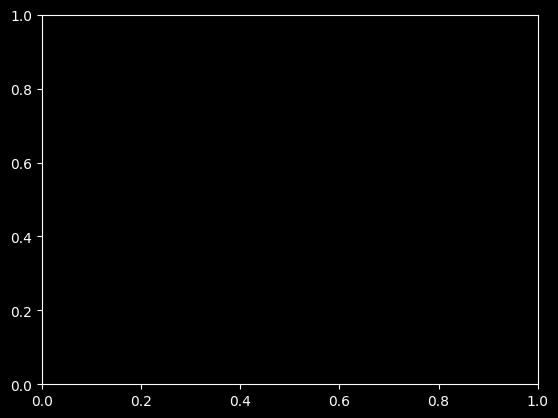

In [16]:
from datasets import sequence
from b2.common.trainer import Trainer
from b2.common.optimizer import Adam
from b2.common.util import to_cpu, to_gpu, eval_seq2seq

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = ((to_gpu(j) for j in i) for i in sequence.load_data('date.txt'))
char_to_id, id_to_char = sequence.get_vocab()

# 입력 문장 반전
x_train, x_test = x_train[:, ::-1], x_test[:, ::-1]

# 하이퍼파라미터 설정
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 256
batch_size = 128
max_epoch = 10
max_grad = 5.0

model = AttentionSeq2seq(vocab_size, wordvec_size, hidden_size)
# model = Seq2seq(vocab_size, wordvec_size, hidden_size)
# model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)

optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
                batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct,
                                    id_to_char, verbose, is_reverse=True)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print('정확도 %.3f%%' % (acc * 100))


model.save_params()


/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/esillileu/abstract-dissection/deep-learning/03_numpy/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

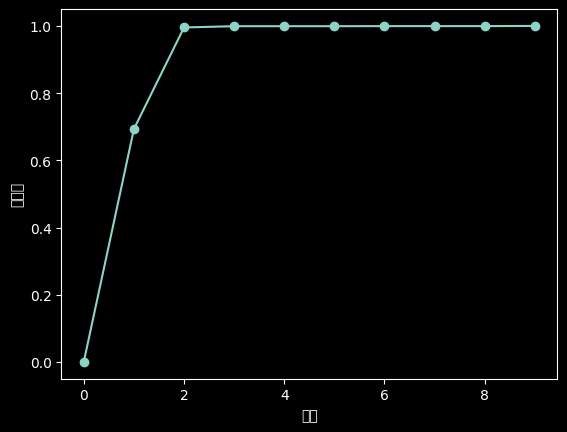

In [19]:

# 그래프 그리기
x = np.arange(len(to_cpu(acc_list)))
plt.plot(to_cpu(x), acc_list, marker='o')
plt.xlabel('에폭')
plt.ylabel('정확도')
plt.ylim(-0.05, 1.05)
plt.show()
